In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score



In [2]:

df = pd.read_csv(r"disaster.csv", encoding="latin-1")

print("Raw dataset shape:", df.shape)
print("\nColumn names:")
for col in df.columns:
    print(" ", col)

Raw dataset shape: (14644, 47)

Column names:
  Dis No
  Year
  Seq
  Glide
  Disaster Group
  Disaster Subgroup
  Disaster Type
  Disaster Subtype
  Disaster Subsubtype
  Event Name
  Country
  ISO
  Region
  Continent
  Location
  Origin
  Associated Dis
  Associated Dis2
  OFDA Response
  Appeal
  Declaration
  Aid Contribution
  Dis Mag Value
  Dis Mag Scale
  Latitude
  Longitude
  Local Time
  River Basin
  Start Year
  Start Month
  Start Day
  End Year
  End Month
  End Day
  Total Deaths
  No Injured
  No Affected
  No Homeless
  Total Affected
  Reconstruction Costs ('000 US$)
  Insured Damages ('000 US$)
  Total Damages ('000 US$)
  CPI
  Adm Level
  Admin1 Code
  Admin2 Code
  Geo Locations


In [3]:
relevant_types = ["Flood", "Storm", "Earthquake", "Wildfire"]

impact_df = df[df["Disaster Type"].isin(relevant_types)].copy()

print("Rows after filtering:", len(impact_df))
print()
print(impact_df["Disaster Type"].value_counts())

Rows after filtering: 10866

Disaster Type
Flood         5272
Storm         4005
Earthquake    1137
Wildfire       452
Name: count, dtype: int64


In [4]:
impact_df = impact_df[[
    "Disaster Type",                       
    "Start Year",                        
    "Region",                             
    "Dis Mag Value",                       
    "Total Affected",                      
    "Total Damages ('000 US$)"    
]].copy()


impact_df.rename(columns={
    "Dis Mag Value":"Magnitude",
    "Total Damages ('000 US$)": "Economic_Damage"
}, inplace=True)

print("Selected columns shape:", impact_df.shape)
print()
print(impact_df.head())

Selected columns shape: (10866, 6)

  Disaster Type  Start Year                     Region  Magnitude  \
0         Flood        1970              South America        NaN   
1         Storm        1970  Australia and New Zealand        NaN   
2         Flood        1970             Western Africa        NaN   
3         Storm        1970              Southern Asia        NaN   
4         Storm        1970              Southern Asia        NaN   

   Total Affected  Economic_Damage  
0             NaN          25000.0  
1             NaN          72475.0  
2             NaN            200.0  
3       3648000.0          86400.0  
4           110.0              NaN  


In [5]:

impact_df = impact_df.dropna(subset=["Total Affected", "Economic_Damage"])
print("After dropping missing targets:", impact_df.shape)

quake_median_mag = impact_df.loc[
    impact_df["Disaster Type"] == "Earthquake", "Magnitude"
].median()

impact_df["Magnitude"] = impact_df.apply(
    lambda row: row["Magnitude"] if pd.notna(row["Magnitude"])
    else (quake_median_mag if row["Disaster Type"] == "Earthquake" else 0),
    axis=1
)


upper_limit = impact_df["Economic_Damage"].quantile(0.99)
impact_df = impact_df[impact_df["Economic_Damage"] <= upper_limit]

print("After removing outliers:", impact_df.shape)
print()


After dropping missing targets: (3571, 6)
After removing outliers: (3535, 6)



In [6]:

features = ["Magnitude", "Start Year", "Disaster Type", "Region"]
X = impact_df[features]

X = pd.get_dummies(X, columns=["Disaster Type", "Region"], drop_first=True)


y_population = np.log1p(impact_df["Total Affected"])
y_economic   = np.log1p(impact_df["Economic_Damage"])

print("Features shape:", X.shape)
print("First 8 feature column names:", X.columns[:8].tolist())

Features shape: (3535, 27)
First 8 feature column names: ['Magnitude', 'Start Year', 'Disaster Type_Flood', 'Disaster Type_Storm', 'Disaster Type_Wildfire', 'Region_Caribbean', 'Region_Central America', 'Region_Central Asia']


In [7]:

X_train, X_test, yp_train, yp_test, ye_train, ye_test = train_test_split(
    X, y_population, y_economic,
    test_size=0.2,
    random_state=42
)

model_population = GradientBoostingRegressor(
    n_estimators=150,    
    learning_rate=0.1, 
    max_depth=4,        
    random_state=42
)
model_population.fit(X_train, yp_train)

model_economic = GradientBoostingRegressor(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)
model_economic.fit(X_train, ye_train)


,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",150
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",4
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [8]:

pop_pred_log  = model_population.predict(X_test)
econ_pred_log = model_economic.predict(X_test)

pop_predicted  = np.expm1(pop_pred_log)
econ_predicted = np.expm1(econ_pred_log)
pop_actual     = np.expm1(yp_test)
econ_actual    = np.expm1(ye_test)

r2_pop   = r2_score(yp_test,  pop_pred_log)
r2_econ  = r2_score(ye_test,  econ_pred_log)
mae_pop  = mean_absolute_error(pop_actual,  pop_predicted)
mae_econ = mean_absolute_error(econ_actual, econ_predicted)


print(f"\n  Population Affected")
print(f"    R² Score : {r2_pop:.4f}")
print(f"    MAE      : {mae_pop:,.0f} people")
print(f"\n  Economic Damage")
print(f"    R² Score : {r2_econ:.4f}")
print(f"    MAE      : ${mae_econ:,.0f} ('000 US$)")



  Population Affected
    R² Score : 0.2905
    MAE      : 1,182,307 people

  Economic Damage
    R² Score : 0.2293
    MAE      : $427,727 ('000 US$)


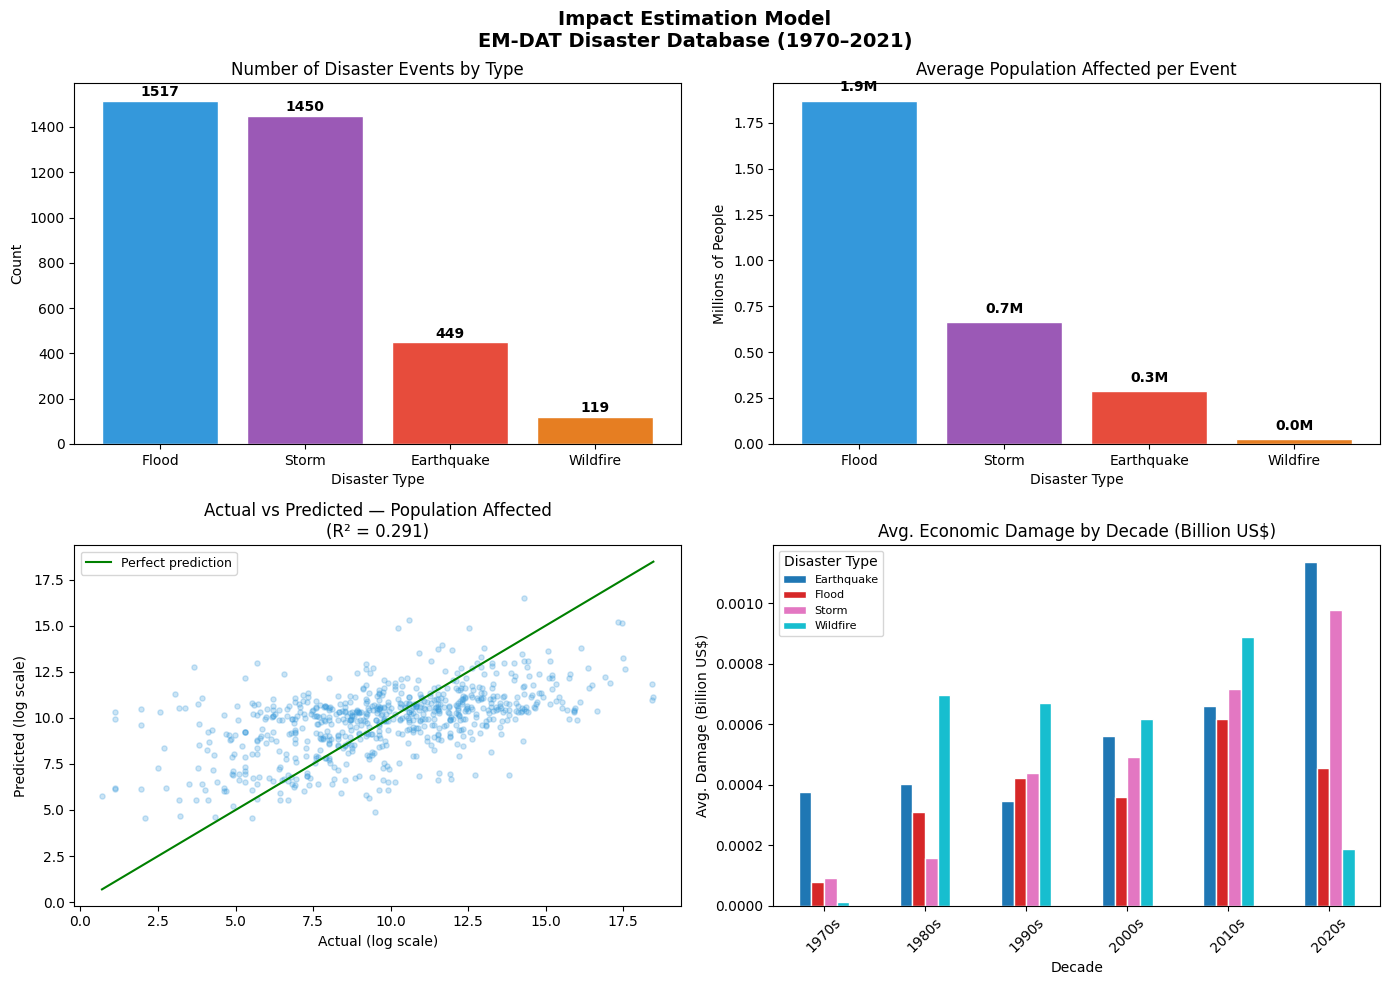

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "Impact Estimation Model\n"
    "EM-DAT Disaster Database (1970–2021)",
    fontsize=14, fontweight="bold"
)

type_colors = ["#3498db", "#9b59b6", "#e74c3c", "#e67e22"]


type_counts = impact_df["Disaster Type"].value_counts()
bars = axes[0, 0].bar(type_counts.index, type_counts.values,
                      color=type_colors, edgecolor="white")
axes[0, 0].set_title("Number of Disaster Events by Type")
axes[0, 0].set_xlabel("Disaster Type")
axes[0, 0].set_ylabel("Count")
for bar, v in zip(bars, type_counts.values):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, v + 20,
                    str(v), ha="center", fontsize=10, fontweight="bold")


avg_pop = (impact_df.groupby("Disaster Type")["Total Affected"]
           .mean().sort_values(ascending=False))
bars2 = axes[0, 1].bar(avg_pop.index, avg_pop.values / 1e6,
                       color=type_colors[:len(avg_pop)], edgecolor="white")
axes[0, 1].set_title("Average Population Affected per Event")
axes[0, 1].set_xlabel("Disaster Type")
axes[0, 1].set_ylabel("Millions of People")
for bar, v in zip(bars2, avg_pop.values):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, v/1e6 + 0.05,
                    f"{v/1e6:.1f}M", ha="center", fontsize=10, fontweight="bold")


axes[1, 0].scatter(yp_test, pop_pred_log, alpha=0.25, s=14, color="#3498db")
mn = min(yp_test.min(), pop_pred_log.min())
mx = max(yp_test.max(), pop_pred_log.max())
axes[1, 0].plot([mn, mx], [mn, mx],color="green", label="Perfect prediction")
axes[1, 0].set_title(f"Actual vs Predicted — Population Affected\n(R² = {r2_pop:.3f})")
axes[1, 0].set_xlabel("Actual (log scale)")
axes[1, 0].set_ylabel("Predicted (log scale)")
axes[1, 0].legend(fontsize=9)


impact_df["Decade"] = (impact_df["Start Year"] // 10 * 10).astype(str) + "s"
decade_damage = (
    impact_df.groupby(["Decade", "Disaster Type"])["Economic_Damage"]
    .mean().unstack(fill_value=0) / 1e9
)
decade_damage = decade_damage[decade_damage.index >= "1960s"]
decade_damage.plot(kind="bar", ax=axes[1, 1],
                   colormap="tab10", edgecolor="white", rot=45)
axes[1, 1].set_title("Avg. Economic Damage by Decade (Billion US$)")
axes[1, 1].set_xlabel("Decade")
axes[1, 1].set_ylabel("Avg. Damage (Billion US$)")
axes[1, 1].legend(fontsize=8, title="Disaster Type")

plt.tight_layout()


In [10]:



import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
import pandas as pd
import numpy as np

type_colors = ["#3498db", "#9b59b6", "#e74c3c", "#e67e22"]
all_types = impact_df["Disaster Type"].unique().tolist()
color_map = {t: type_colors[i % len(type_colors)] for i, t in enumerate(all_types)}

def plot_impact_dashboard(year_range):
    filtered = impact_df[
        (impact_df["Start Year"] >= year_range[0]) &
        (impact_df["Start Year"] <= year_range[1])
    ].copy()

    if filtered.empty:
        print("No data available for selected year range.")
        return

    filtered["Decade"] = (filtered["Start Year"] // 10 * 10).astype(str) + "s"

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(
        f"Impact Estimation Model\nEM-DAT Disaster Database ({year_range[0]}–{year_range[1]})",
        fontsize=14, fontweight="bold"
    )

    type_counts = filtered["Disaster Type"].value_counts()
    bar_colors_1 = [color_map[t] for t in type_counts.index]
    bars = axes[0, 0].bar(type_counts.index, type_counts.values,
                          color=bar_colors_1, edgecolor="white")
    axes[0, 0].set_title("Number of Disaster Events by Type")
    axes[0, 0].set_xlabel("Disaster Type")
    axes[0, 0].set_ylabel("Count")
    for bar, v in zip(bars, type_counts.values):
        axes[0, 0].text(bar.get_x() + bar.get_width()/2, v + max(type_counts.values) * 0.01,
                        str(v), ha="center", fontsize=10, fontweight="bold")

    avg_pop = (filtered.groupby("Disaster Type")["Total Affected"]
               .mean().sort_values(ascending=False))
    bar_colors_2 = [color_map[t] for t in avg_pop.index]
    bars2 = axes[0, 1].bar(avg_pop.index, avg_pop.values / 1e6,
                            color=bar_colors_2, edgecolor="white")
    axes[0, 1].set_title("Average Population Affected per Event")
    axes[0, 1].set_xlabel("Disaster Type")
    axes[0, 1].set_ylabel("Millions of People")
    for bar, v in zip(bars2, avg_pop.values):
        axes[0, 1].text(bar.get_x() + bar.get_width()/2, v / 1e6 + max(avg_pop.values) / 1e6 * 0.01,
                        f"{v/1e6:.1f}M", ha="center", fontsize=10, fontweight="bold")

    axes[1, 0].scatter(yp_test, pop_pred_log, alpha=0.25, s=14, color="#3498db")
    mn = min(yp_test.min(), pop_pred_log.min())
    mx = max(yp_test.max(), pop_pred_log.max())
    axes[1, 0].plot([mn, mx], [mn, mx], color="green", label="Perfect prediction")
    axes[1, 0].set_title(f"Actual vs Predicted — Population Affected\n(R² = {r2_pop:.3f})")
    axes[1, 0].set_xlabel("Actual (log scale)")
    axes[1, 0].set_ylabel("Predicted (log scale)")
    axes[1, 0].legend(fontsize=9)

    decade_damage = (
        filtered.groupby(["Decade", "Disaster Type"])["Economic_Damage"]
        .mean().unstack(fill_value=0) / 1e9
    )
    plot_colors = [color_map[c] for c in decade_damage.columns if c in color_map]
    decade_damage.plot(kind="bar", ax=axes[1, 1],
                       color=plot_colors, edgecolor="white", rot=45)
    axes[1, 1].set_title("Avg. Economic Damage by Decade (Billion US$)")
    axes[1, 1].set_xlabel("Decade")
    axes[1, 1].set_ylabel("Avg. Damage (Billion US$)")
    axes[1, 1].legend(fontsize=8, title="Disaster Type")

    plt.tight_layout()
    plt.show()

min_year = int(impact_df["Start Year"].min())
max_year = int(impact_df["Start Year"].max())

year_range_slider = widgets.IntRangeSlider(
    value=[1970, 2021],
    min=min_year,
    max=max_year,
    step=1,
    description="Year Range:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="500px")
)

out = widgets.interactive_output(plot_impact_dashboard, {"year_range": year_range_slider})
display(year_range_slider, out)

IntRangeSlider(value=(1970, 2021), description='Year Range:', layout=Layout(width='500px'), max=2021, min=1970…

Output()

In [1]:

import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D



BG     = "#0d1117"
PANEL  = "#161b22"
GRID_C = "#21262d"
TEXT   = "#e6edf3"
DIM    = "#8b949e"
ACCENT = "#58a6ff"

TYPE_PALETTE = ["#3498db", "#9b59b6", "#e74c3c", "#e67e22",
                "#1abc9c", "#e91e63", "#ff9800", "#00bcd4"]

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor":   PANEL,
    "axes.edgecolor":   GRID_C,
    "axes.labelcolor":  DIM,
    "axes.titlecolor":  TEXT,
    "axes.grid":        True,
    "grid.color":       GRID_C,
    "grid.linewidth":   0.6,
    "xtick.color":      DIM,
    "ytick.color":      DIM,
    "text.color":       TEXT,
    "font.family":      "monospace",
    "legend.facecolor": PANEL,
    "legend.edgecolor": GRID_C,
})


all_types = sorted(impact_df["Disaster Type"].unique().tolist())
color_map  = {t: TYPE_PALETTE[i % len(TYPE_PALETTE)] for i, t in enumerate(all_types)}


def plot_impact_dashboard(year_range):
    data = impact_df[
        (impact_df["Start Year"] >= year_range[0]) &
        (impact_df["Start Year"] <= year_range[1])
    ].copy()

    if data.empty:
        print("No data for selected year range.")
        return

    data["Decade"] = (data["Start Year"] // 10 * 10).astype(str) + "s"

    n       = len(data)
    tot_aff = data["Total Affected"].sum()
    tot_dmg = data["Economic_Damage"].sum() / 1e9

    fig = plt.figure(figsize=(18, 13), facecolor=BG)
    fig.suptitle(
        f"SafeSphere  ·  Impact Estimation Model  ·  {year_range[0]}–{year_range[1]}"
        f"        Events: {n:,}  |  Affected: {tot_aff/1e6:.1f}M  |  Damage: ${tot_dmg:.1f}B",
        fontsize=13, fontweight="bold", color=TEXT, y=0.97
    )

    gs = gridspec.GridSpec(
        2, 3,
        figure=fig,
        hspace=0.45, wspace=0.38,
        top=0.91, bottom=0.07,
        left=0.06, right=0.97
    )

    ax1 = fig.add_subplot(gs[0, :])

    type_counts  = data["Disaster Type"].value_counts()
    bar_colors_1 = [color_map[t] for t in type_counts.index]
    bars         = ax1.bar(
        type_counts.index, type_counts.values,
        color=bar_colors_1, alpha=0.88,
        edgecolor=BG, linewidth=1.2, zorder=3
    )
    ax1.fill_between(range(len(type_counts)), type_counts.values,
                     alpha=0.06, color=ACCENT)

    for bar, v in zip(bars, type_counts.values):
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            v + max(type_counts.values) * 0.012,
            str(v), ha="center", fontsize=10,
            fontweight="bold", color=TEXT
        )

    ax1.set_title(
        f"Disaster Events by Type  ·  {year_range[0]}–{year_range[1]}",
        fontsize=11, pad=10
    )
    ax1.set_xlabel("Disaster Type", fontsize=9)
    ax1.set_ylabel("Number of Events", fontsize=9)
    ax1.set_ylim(0, type_counts.values.max() * 1.18)
    ax1.legend(
        handles=[mpatches.Patch(color=color_map[t], label=t) for t in type_counts.index],
        fontsize=8, loc="upper right", framealpha=0.3, ncol=len(type_counts)
    )

    ax2 = fig.add_subplot(gs[1, 0], projection="3d")
    ax2.set_facecolor(PANEL)

    decades        = sorted(data["Decade"].unique())
    types_in_data  = [t for t in all_types if t in data["Disaster Type"].values]

    xpos_all, ypos_all, zpos_all = [], [], []
    dx_all, dy_all, dz_all, col_all = [], [], [], []

    for xi, decade in enumerate(decades):
        for yi, dtype in enumerate(types_in_data):
            sub = data[
                (data["Decade"] == decade) &
                (data["Disaster Type"] == dtype)
            ]["Total Affected"]
            val = float(sub.mean()) / 1e6 if not sub.empty else 0
            xpos_all.append(xi * 1.3)
            ypos_all.append(yi * 1.4)
            zpos_all.append(0)
            dx_all.append(1.0)
            dy_all.append(1.0)
            dz_all.append(max(val, 0))
            col_all.append(color_map[dtype])

    ax2.bar3d(xpos_all, ypos_all, zpos_all,
              dx_all, dy_all, dz_all,
              color=col_all, alpha=0.82, shade=True)

    ax2.set_title("3D: Avg Population\nAffected (M) · Decade × Type",
                  fontsize=9, pad=6)
    ax2.set_xticks([i * 1.3 + 0.5 for i in range(len(decades))])
    ax2.set_xticklabels(decades, fontsize=5.5, rotation=15)
    ax2.set_yticks([i * 1.4 + 0.5 for i in range(len(types_in_data))])
    ax2.set_yticklabels(types_in_data, fontsize=6)
    ax2.set_zlabel("Millions", fontsize=7, labelpad=2)
    ax2.tick_params(colors=DIM, labelsize=6)
    ax2.xaxis.pane.fill = False
    ax2.yaxis.pane.fill = False
    ax2.zaxis.pane.fill = False
    ax2.xaxis.pane.set_edgecolor(GRID_C)
    ax2.yaxis.pane.set_edgecolor(GRID_C)
    ax2.zaxis.pane.set_edgecolor(GRID_C)
    ax2.view_init(elev=26, azim=-55)

    ax3 = fig.add_subplot(gs[1, 1])

    ax3.scatter(yp_test, pop_pred_log,
                alpha=0.25, s=16, color=ACCENT, zorder=3)
    mn = min(yp_test.min(), pop_pred_log.min())
    mx = max(yp_test.max(), pop_pred_log.max())
    ax3.plot([mn, mx], [mn, mx], color="#00c853",
             lw=1.8, label="Perfect prediction", zorder=4)
    ax3.fill_between([mn, mx], [mn, mx], alpha=0.04, color="#00c853")
    ax3.set_title(
        f"Actual vs Predicted — Population Affected\n(R² = {r2_pop:.3f})",
        fontsize=9, pad=8
    )
    ax3.set_xlabel("Actual (log scale)", fontsize=8)
    ax3.set_ylabel("Predicted (log scale)", fontsize=8)
    ax3.legend(fontsize=8, framealpha=0.3)

    ax4 = fig.add_subplot(gs[1, 2])

    decade_damage = (
        data.groupby(["Decade", "Disaster Type"])["Economic_Damage"]
        .mean().unstack(fill_value=0) / 1e9
    )
    decade_damage = decade_damage[decade_damage.index >= "1960s"]

    x      = np.arange(len(decade_damage.index))
    n_cols = len(decade_damage.columns)
    width  = 0.8 / max(n_cols, 1)

    for i, col in enumerate(decade_damage.columns):
        c = color_map.get(col, TYPE_PALETTE[i % len(TYPE_PALETTE)])
        ax4.bar(
            x + i * width,
            decade_damage[col].values,
            width, color=c, alpha=0.85,
            edgecolor=BG, linewidth=0.8,
            label=col, zorder=3
        )

    ax4.set_title("Avg. Economic Damage by Decade (Billion US$)",
                  fontsize=9, pad=8)
    ax4.set_xlabel("Decade", fontsize=8)
    ax4.set_ylabel("Avg. Damage (B USD)", fontsize=8)
    ax4.set_xticks(x + width * n_cols / 2)
    ax4.set_xticklabels(decade_damage.index, fontsize=7.5, rotation=35)
    ax4.legend(fontsize=7, title="Type", title_fontsize=7,
               framealpha=0.3, loc="upper left")

    plt.show()



min_year = int(impact_df["Start Year"].min())
max_year = int(impact_df["Start Year"].max())

year_slider = widgets.IntRangeSlider(
    value=[1970, max_year],
    min=min_year,
    max=max_year,
    step=1,
    description="",
    layout=widgets.Layout(width="520px")
)

year_label = widgets.HTML(
    value=f"<span style='font-family:monospace;color:#58a6ff;"
          f"font-size:14px;font-weight:bold'>1970 — {max_year}</span>"
)

def on_slider_change(change):
    v = change["new"]
    year_label.value = (
        f"<span style='font-family:monospace;color:#58a6ff;"
        f"font-size:14px;font-weight:bold'>{v[0]} — {v[1]}</span>"
    )

year_slider.observe(on_slider_change, names="value")

header = widgets.HTML("""
<div style='
  background:#161b22;
  border:1px solid #21262d;
  border-radius:10px;
  padding:12px 20px;
  margin-bottom:8px;
  font-family:monospace;
'>
  <span style='color:#58a6ff;font-size:13px;letter-spacing:2px'>
    🌍 SAFESPHERE  ·  IMPACT ESTIMATION MODEL  ·  EM-DAT DATABASE
  </span><br>
  <span style='color:#8b949e;font-size:11px'>
    Drag the slider to explore any year range · all 4 graphs update simultaneously
  </span>
</div>
""")

controls = widgets.HBox(
    [widgets.HTML("<span style='font-family:monospace;color:#8b949e;"
                  "font-size:11px;white-space:nowrap'>Year Range →</span>"),
     year_slider,
     year_label],
    layout=widgets.Layout(
        align_items="center", gap="14px",
        padding="10px 16px",
        border="1px solid #21262d",
        border_radius="8px",
        margin="0 0 14px 0"
    )
)

out = widgets.interactive_output(
    plot_impact_dashboard,
    {"year_range": year_slider}
)

display(header, controls, out)


NameError: name 'plt' is not defined